[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/covinolab/diff_fret_likelihood/blob/main/tutorial/smfret_likelihood_tutorial.ipynb)

# Free energy landscapes from single photons

`diff_fret_likelihood` fits a **continuous** free energy landscape $U(x)$ and a diffusion coefficient $D$ directly to smFRET photon arrival times — no binning, no hidden states, no FRET-efficiency histogram in between.

This notebook simulates a molecule diffusing on a double well, looks at the raw photons, and recovers the landscape. Everything hard (background, crosstalk, fitting $D$) is switched off but present as a variable, so you can turn it on one line at a time.

A Colab **GPU** runtime is several times faster than CPU: *Runtime → Change runtime type → T4 GPU*.

In [295]:
import sys, time

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # GSL is a system library the photon simulator compiles against.
    !apt-get -qq install -y libgsl-dev pkg-config
    !pip install -q git+https://github.com/covinolab/diff_fret_likelihood.git

import numpy as np
import torch
import scipy as sp
import matplotlib.pyplot as plt
import diff_fret_likelihood as dfl
from diff_fret_likelihood.simulator import eval_spline

dfl.use_float64()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"dfl {dfl.__version__} | torch {torch.__version__} | device: {device}")

dfl 0.4.0 | torch 2.5.1+cu124 | device: cuda


## The ground truth energy landscape
A simple double well potential. The diffusion coefficient is set to $D = 4.5$ nm²/ms.

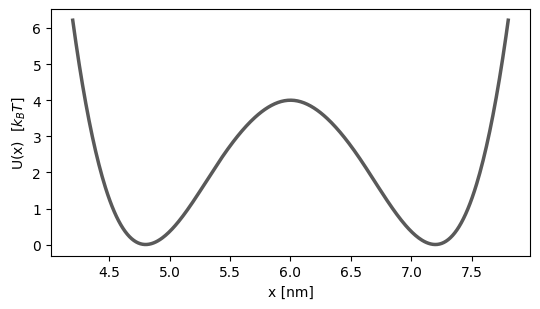

In [335]:
R0      = 6.0                                                 # Förster radius, nm
x_knots = np.linspace(2.0, 10.0, 15)                          # nm
y_knots = 4.0 * (((x_knots - 6.0) / 1.2) ** 2 - 1.0) ** 2     # U at the knots, kT

X_MIN, X_MAX = 4.25, 7.75        # the window we will fit on

def U_true(x):
    """Ground-truth U(x) in kT: the natural cubic spline through the knots."""
    return np.asarray(eval_spline(x_knots, y_knots, np.asarray(x, float)), float)

def E_fret(x):
    """Förster efficiency E(x) = R0^6 / (R0^6 + x^6)."""
    return dfl.fret_efficiency(torch.as_tensor(np.asarray(x, float)), R0).numpy()

xs = np.linspace(4.2, 7.8, 400)
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(xs, U_true(xs), color="0.35", lw=2.5, label="U(x)")
ax.set(xlabel="x [nm]", ylabel="U(x)  [$k_BT$]")
fig.tight_layout()

## Photophysics

Every switch is a variable. The values on the right of each comment are realistic ones — change a line and rerun from here to see what that complication costs you.

In [352]:
D_true         = 2.5        # diffusion coefficient, nm^2/ms   (held FIXED in the fit)

kD             = 30.0       # donor brightness, kHz
eta_g, eta_r   = 1.0, 1.0   # detection efficiencies    
beta_g, beta_r = 0.0, 0.0   # detected background, kHz   
C_gr, C_rg     = 0.0, 0.0   # channel crosstalk 

T, dt          = 100.0, 5e-6   # trace length and Langevin step, ms
n_traces, seed = 50, 0

FIT_D          = False      # True also fits D (slower, and wants more photons)

## Simulate photon traces

Each trace starts from the Boltzmann distribution of $U$, diffuses, and emits green or red photons at rates set by its instantaneous $E(x)$.

In [353]:
t0 = time.time()
batch = dfl.simulate.simulate_equilibrium(
    x_knots, y_knots, D_true, R0, kD, beta_g, beta_r, eta_g, eta_r, C_gr, C_rg,
    T=T, dt=dt, n_traces=n_traces, seed=seed,
)
print(f"{int(batch.lengths.sum())} photons in {time.time() - t0:.0f} s")

50/50 traces in 4.6s | photons/trace min/med/max = [2865 2989 3124] | workers=24
149579 photons in 5 s


## What the data actually looks like

The ticks are the entire measurement: one green or red mark per photon. The line is the apparent efficiency in 0.5 ms bins — the standard first move, and already a compromise, since a bin short enough to follow the motion holds too few photons to pin down $E$.

The likelihood below never bins.

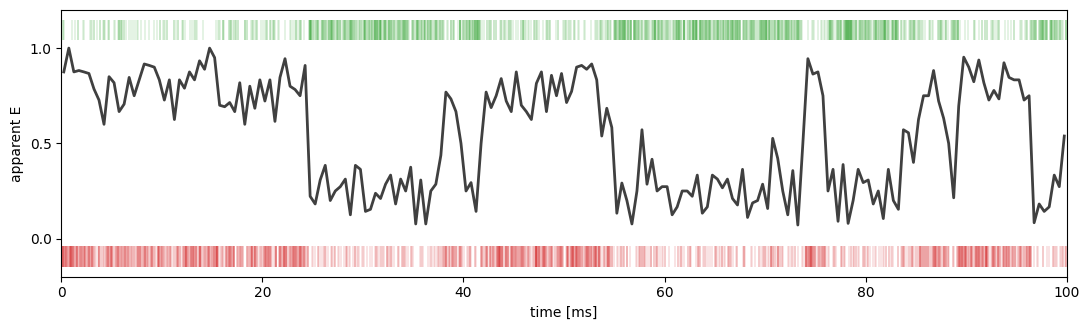

In [357]:
BIN_MS = 0.5

def photon_times(b):
    """Arrival times [ms] and colours (0 = green, 1 = red) of trace b."""
    n = int(batch.lengths[b])
    return np.cumsum(batch.ipt[b, :n].numpy()), batch.colors[b, :n].numpy()

def binned_E(t, c, bin_ms, t_max):
    """Apparent efficiency per time bin: n_red / (n_red + n_green)."""
    edges = np.arange(0.0, t_max + bin_ms, bin_ms)
    n_g = np.histogram(t[c == 0], bins=edges)[0]
    n_r = np.histogram(t[c == 1], bins=edges)[0]
    tot = n_g + n_r
    return 0.5 * (edges[:-1] + edges[1:]), np.where(tot > 0, n_r / np.maximum(tot, 1), np.nan)

# pick whichever trace moved most (coarse bins, only used to choose one to draw)
spread = [np.nanstd(binned_E(*photon_times(b), 5.0, T)[1]) for b in range(batch.n_traces)]
b_show = int(np.nanargmax(spread))
t, c = photon_times(b_show)
tb, Eb = binned_E(t, c, BIN_MS, T)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.vlines(t[c == 0], 1.04, 1.15, color="tab:green", lw=0.3, alpha=0.6)
ax.vlines(t[c == 1], -0.15, -0.04, color="tab:red", lw=0.3, alpha=0.6)
ax.plot(tb, Eb, color="0.25", lw=2)
ax.set(xlabel="time [ms]", ylabel="apparent E", xlim=(0, T), ylim=(-0.2, 1.2), yticks=[0.0, 0.5, 1.0])
fig.tight_layout()

## The likelihood

Instead of binning, write down the probability of the exact photon record. Between two photons the position density is propagated by the Smoluchowski operator for $U$ and $D$, *minus* the emission rates — that dark interval is itself evidence about where the molecule was. Each photon then multiplies in the rate of its own colour at each position, and at the end position is integrated out.

$U$ is represented by the heights of a cubic spline on a grid, starting flat, so no landscape is smuggled in. Only *differences* in $U$ are identifiable — shifting the whole landscape up is the same physics — so results are reported with the grid mean set to zero.

In [358]:
grid      = dfl.GridConfig(x_min=X_MIN, x_max=X_MAX, n_grid=160).build(device)
potential = dfl.build_potential(dfl.PotentialConfig(n_knots=11), grid).to(device)

consts = dfl.PhysicsConstants(R0=R0, C_gg=1.0 - C_gr, C_gr=C_gr,
                              C_rg=C_rg, C_rr=1.0 - C_rg)
C      = consts.crosstalk_tensor(device)
rates  = dfl.EffectiveRates.from_physics(kD, eta_g, eta_r, beta_g, beta_r, device=device)
prior  = dfl.PriorConfig(curvature_weight=0.003)     # mild smoothness on U

on_gpu = device == "cuda"
optim  = dfl.OptimConfig(steps=300, stop_patience=25, log_every=10,
                         lbfgs_lr=0.1, 
                         compile=on_gpu,
                         propagate_dtype=torch.float32 if on_gpu else None)
batch_dev = batch.to(device)

## Run the fit

Guarded LBFGS on the 11 knot heights. `fit_D=False` freezes $D$ at its true value and `fit_rates=False` freezes the photophysics, which is what keeps this demo short.

`stop_reason` should read `plateau@N` or `converged@N`. `recovered@N` means a step blew up and the best earlier state was restored — usually too little data or a grid reaching too far.

In [359]:
t0  = time.time()
res = dfl.fit(batch_dev, grid, potential, C, R0,
              D_init=D_true, rates_init=rates, prior=prior, optim=optim,
              fit_D=FIT_D, fit_rates=False)
print(f"\n{time.time() - t0:.0f} s   D = {res.D:.2f} nm^2/ms   stop: {res.stop_reason}")

  [lbfgs    0] loss=-270584.882  D=2.500  best=-270584.882
  [lbfgs   10] loss=-272885.891  D=2.500  best=-272885.891
  [lbfgs   20] loss=-273219.845  D=2.500  best=-273219.845
  [lbfgs   30] loss=-273258.607  D=2.500  best=-273258.607
  [lbfgs   40] loss=-273265.559  D=2.500  best=-273265.559
  [lbfgs   50] loss=-273267.894  D=2.500  best=-273267.894
  [lbfgs   60] loss=-273269.767  D=2.500  best=-273269.767
  [lbfgs   70] loss=-273270.766  D=2.500  best=-273270.766
  [lbfgs   80] loss=-273271.138  D=2.500  best=-273271.138
  [lbfgs] stop: plateau@89  best=-273271.454  D=2.500

35 s   D = 2.50 nm^2/ms   stop: plateau@89


## The recovered landscape

Both curves are shifted to zero mean before comparing, since the offset is not identifiable.

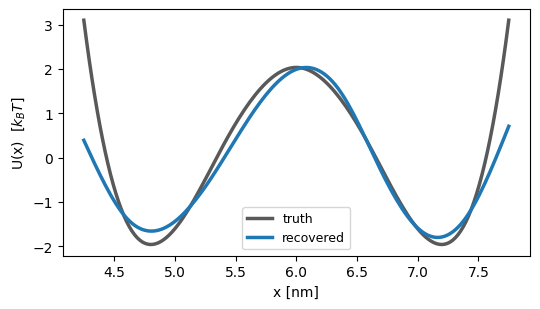

In [362]:
x     = grid.cpu().numpy()
U_t   = U_true(x) - U_true(x).mean()

U_rec = dfl.recovered_potential(res.potential, grid).cpu().numpy()
opt_shift = sp.optimize.minimize_scalar(lambda n: (np.abs((U_rec[20:-20] + n - U_t[20:-20]))).sum(), bounds=(-10, 10.0), method="bounded")
opt_shift = opt_shift.x 
U_rec += opt_shift

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(x, U_t, color="0.35", lw=2.5, label="truth")
ax.plot(x, U_rec, color="tab:blue", lw=2.5, label="recovered")
ax.set(xlabel="x [nm]", ylabel="U(x)  [$k_BT$]")
ax.legend(fontsize=9)
fig.tight_layout()

## Error bars

The Cramér–Rao bound turns the curvature of the likelihood into the tightest error bars any unbiased estimator could achieve on this dataset. The band is projected into the same zero-mean gauge as the curves above; without that projection the per-knot numbers are dominated by the arbitrary offset.

`null_dim` counts directions the data cannot constrain at all. Expect **2** here: with `beta_g = beta_r = 0` there is no background, so the two background rates are unidentifiable. Turn the background on and it drops to 0.

sigma_D = 0.41 nm^2/ms  (the bound if D were fitted too)
unconstrained directions: 2


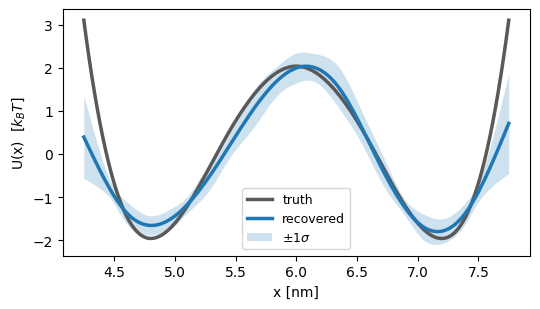

In [363]:
def sigma_U(potential, grid, crb):
    """1 sigma on U(x), in the same zero-mean gauge as `recovered_potential`."""
    Bc = potential._basis(grid).detach().cpu().numpy()      # U(grid) = Bc @ theta
    Bc = Bc - Bc.mean(axis=0, keepdims=True)
    K = Bc.shape[1]
    cov = crb.cov.detach().cpu().numpy()[:K, :K]            # the knot block
    return np.sqrt(np.clip(np.einsum("gi,ij,gj->g", Bc, cov, Bc), 0.0, None))

crb = dfl.cramer_rao_bound(batch_dev, grid, res.potential, res.D, res.rates,
                           C=C, R0=R0, prior=prior)
sig = sigma_U(res.potential, grid, crb)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(x, U_t, color="0.35", lw=2.5, label="truth")
ax.plot(x, U_rec, color="tab:blue", lw=2.5, label="recovered")
ax.fill_between(x, U_rec - sig, U_rec + sig, color="tab:blue", alpha=0.22, lw=0,
                label=r"$\pm 1\sigma$")
ax.set(xlabel="x [nm]", ylabel="U(x)  [$k_BT$]")
ax.legend(fontsize=9)
fig.tight_layout()

print(f"sigma_D = {crb.sigma_physical['D']:.2f} nm^2/ms  (the bound if D were fitted too)")
print(f"unconstrained directions: {crb.null_dim}")